# EDSR Training Demo (with torch.compile)

A small, interactive sibling of `src/training/train.py`. Same building blocks, scaled down for quick iteration:

- 5 epochs (vs 200 in the script)
- Batch 4, LR patch 64 (vs 16 / 96 in the script)
- Live loss + val PSNR plot at the end
- A direct eager-vs-compiled timing comparison
- Visual before/after on a validation sample

Don't expect impressive PSNR numbers from 5 epochs — the goal here is to verify the full loop runs end-to-end and to give you a feel for the moving parts.

In [1]:
# Cell 1 - imports, device, config
import os, sys, math, time, random

_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.data.dataset import SRDataset
from src.models.edsr import EDSR

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"  {p.name} | {p.total_memory/1e9:.1f} GB | SM {p.major}.{p.minor}")

# Small config for the notebook -- favors fast iteration over PSNR
SCALE = 2
PATCH_LR = 64           # HR patch = PATCH_LR * SCALE = 128
BATCH_SIZE = 4
EPOCHS = 5
LR_INIT = 1e-4
SEED = 42

USE_COMPILE = (DEVICE.type == "cuda")  # triton-windows installed
COMPILE_MODE = "default"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

PyTorch 2.6.0+cu124 | device: cuda
  NVIDIA GeForce RTX 3060 Laptop GPU | 6.4 GB | SM 8.6


## Cell 2 - dataset + sample preview

Build train and val datasets pointing at DIV2K. Show one HR/LR pair so we can sanity-check the degradation pipeline visually before training kicks off.

train: 800 HR images | val: 100 HR images
LR tensor: (3, 64, 64) | HR tensor: (3, 128, 128)


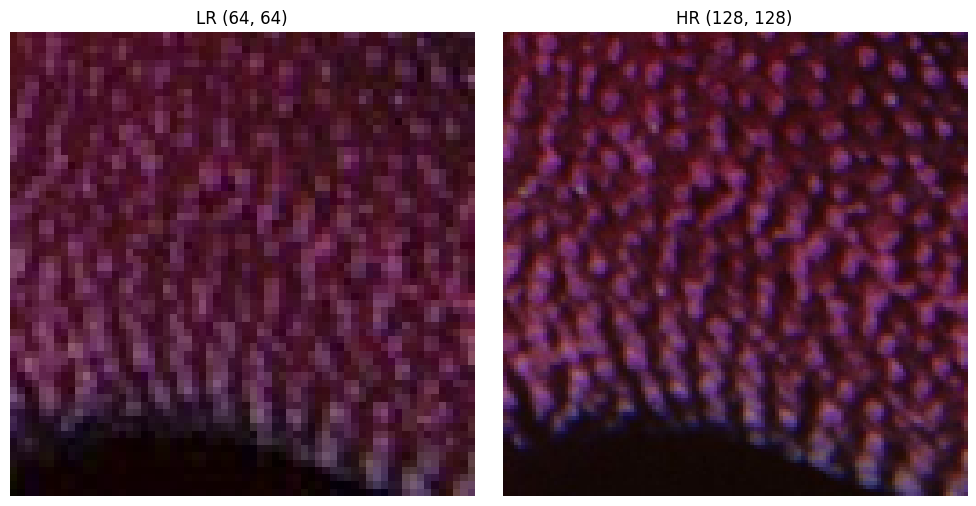

In [2]:
# Cell 2 - datasets and one sample
train_set = SRDataset(
    hr_dir=os.path.join(_PROJECT_ROOT, "data", "DIV2K", "DIV2K_train_HR"),
    scale=SCALE, hr_patch_size=PATCH_LR * SCALE,
    degradation="realistic", is_train=True,
)
val_set = SRDataset(
    hr_dir=os.path.join(_PROJECT_ROOT, "data", "DIV2K", "DIV2K_valid_HR"),
    scale=SCALE, hr_patch_size=PATCH_LR * SCALE,
    degradation="realistic", is_train=False,
)
print(f"train: {len(train_set)} HR images | val: {len(val_set)} HR images")

# DataLoaders -- num_workers=0 so the notebook stays single-process (Windows-friendly)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Show one HR/LR pair from training set (random crop + augmentation each call)
lr, hr = train_set[0]
print(f"LR tensor: {tuple(lr.shape)} | HR tensor: {tuple(hr.shape)}")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lr.permute(1, 2, 0).numpy()); axes[0].set_title(f"LR {tuple(lr.shape[1:])}"); axes[0].axis("off")
axes[1].imshow(hr.permute(1, 2, 0).numpy()); axes[1].set_title(f"HR {tuple(hr.shape[1:])}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Cell 3 - model, optional torch.compile, eager-vs-compiled timing

Build EDSR-baseline (16 ResBlocks, 64 feats, 2x). Wrap it in `torch.compile` if CUDA is available. Then measure forward-pass latency for both versions on the actual training input shape so we know what the speedup is on _this_ hardware before committing to it for the run.

In [3]:
# Cell 3 - build model and time eager vs compiled
eager_model = EDSR(scale_factor=SCALE, n_resblocks=16, n_feats=64).to(DEVICE)
n_params = sum(p.numel() for p in eager_model.parameters())
print(f"EDSR params: {n_params:,}")

if USE_COMPILE:
    print(f"Compiling with mode='{COMPILE_MODE}' ... (first call will pay the compile cost)")
    model = torch.compile(eager_model, mode=COMPILE_MODE)
else:
    model = eager_model
    print("torch.compile disabled (no CUDA or USE_COMPILE=False)")

# Benchmark forward pass latency at the training input shape
if DEVICE.type == "cuda":
    dummy = torch.randn(BATCH_SIZE, 3, PATCH_LR, PATCH_LR, device=DEVICE)

    def time_forward(m, n_iter=30, n_warmup=5):
        m.eval()
        with torch.no_grad():
            for _ in range(n_warmup):
                _ = m(dummy)
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            for _ in range(n_iter):
                _ = m(dummy)
        torch.cuda.synchronize()
        return (time.time() - t0) / n_iter * 1000

    t_eager = time_forward(eager_model)
    if USE_COMPILE:
        t_compiled = time_forward(model)
        print(f"  eager forward    : {t_eager:.2f} ms")
        print(f"  compiled forward : {t_compiled:.2f} ms")
        print(f"  speedup          : {t_eager / t_compiled:.2f}x")
        print("  (training speedup is usually larger -- backward pass benefits too)")
    else:
        print(f"  eager forward    : {t_eager:.2f} ms")

# Optimizer / loss / scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
criterion = nn.L1Loss()

EDSR params: 1,369,859
Compiling with mode='default' ... (first call will pay the compile cost)


W0426 16:51:27.234000 5284 .venv\Lib\site-packages\torch\_inductor\utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


  eager forward    : 9.03 ms
  compiled forward : 7.79 ms
  speedup          : 1.16x
  (training speedup is usually larger -- backward pass benefits too)


## Cell 4 - training loop with live loss / val-PSNR

Standard SR training loop: forward -> L1 loss -> backward -> Adam step. Validation PSNR computed on a slice of the val set after each epoch (full val set is small, so we do all of it). Loss + PSNR plotted at the end.

epoch 1/5 | loss 0.0639 | val PSNR 23.64 dB | 87.1s


epoch 2/5 | loss 0.0380 | val PSNR 25.24 dB | 64.0s


epoch 3/5 | loss 0.0331 | val PSNR 25.97 dB | 58.5s


epoch 4/5 | loss 0.0331 | val PSNR 25.90 dB | 58.3s


epoch 5/5 | loss 0.0333 | val PSNR 26.03 dB | 59.0s
total wall: 326.8s


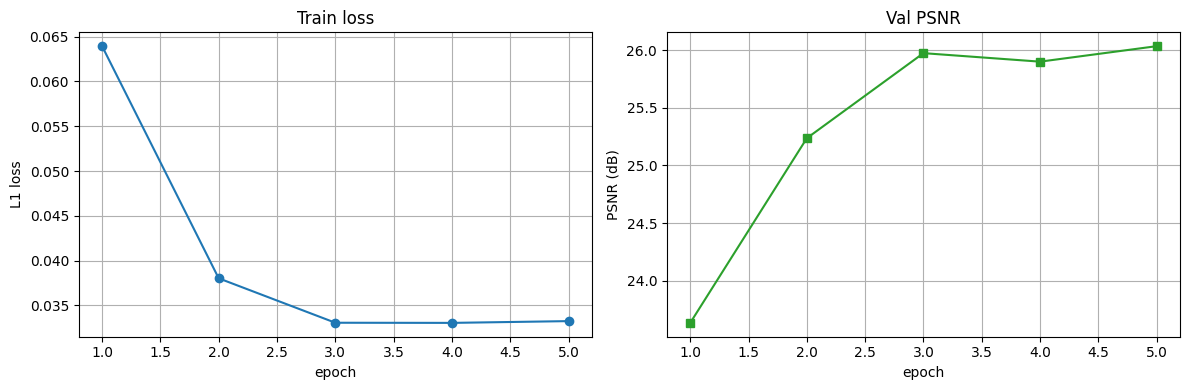

In [4]:
# Cell 4 - training loop (5 epochs, small config -- ~minutes on RTX 3060)
@torch.no_grad()
def quick_psnr(m, loader, device):
    m.eval()
    psnr_sum, count = 0.0, 0
    for lr_b, hr_b in loader:
        lr_b = lr_b.to(device, non_blocking=True)
        hr_b = hr_b.to(device, non_blocking=True)
        sr_b = m(lr_b).clamp(0.0, 1.0)
        mse = ((sr_b - hr_b) ** 2).mean(dim=(1, 2, 3))
        psnr = 10.0 * torch.log10(1.0 / mse.clamp(min=1e-10))
        psnr_sum += psnr.sum().item()
        count += psnr.numel()
    return psnr_sum / max(count, 1)

train_losses = []
val_psnrs = []

wall_start = time.time()
for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n = 0.0, 0
    t0 = time.time()
    for lr_b, hr_b in train_loader:
        lr_b = lr_b.to(DEVICE, non_blocking=True)
        hr_b = hr_b.to(DEVICE, non_blocking=True)
        sr_b = model(lr_b)
        loss = criterion(sr_b, hr_b)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item(); n += 1
    scheduler.step()
    avg_loss = epoch_loss / n
    train_losses.append(avg_loss)
    psnr = quick_psnr(model, val_loader, DEVICE)
    val_psnrs.append(psnr)
    print(f"epoch {epoch+1}/{EPOCHS} | loss {avg_loss:.4f} | val PSNR {psnr:.2f} dB | {time.time()-t0:.1f}s")
print(f"total wall: {time.time()-wall_start:.1f}s")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, "o-")
ax1.set_xlabel("epoch"); ax1.set_ylabel("L1 loss"); ax1.set_title("Train loss"); ax1.grid(True)
ax2.plot(range(1, EPOCHS+1), val_psnrs, "s-", color="tab:green")
ax2.set_xlabel("epoch"); ax2.set_ylabel("PSNR (dB)"); ax2.set_title("Val PSNR"); ax2.grid(True)
plt.tight_layout(); plt.show()

## Cell 5 - visual before/after on a validation sample

Pick a val image, push it through the trained model, and compare against the bicubic baseline. After only 5 epochs, the SR output may not visibly beat bicubic — the point is to verify the full eval path works (LR -> model -> SR tensor -> display) and to set up the comparison panel for when you do a longer run.

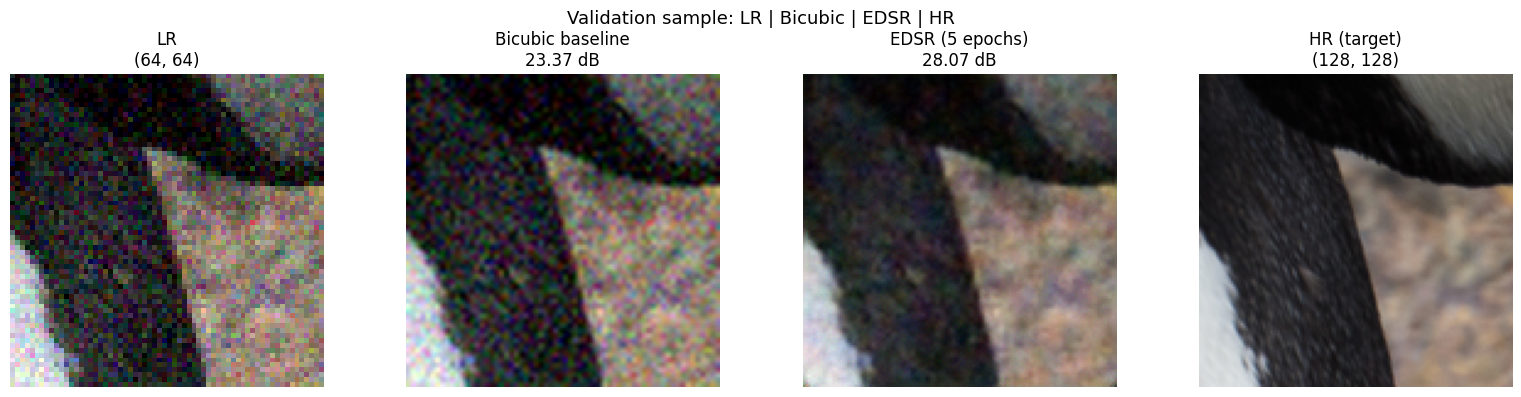

Done. To train properly, run from the project root:
  python -m src.training.train --compile --epochs 200


In [5]:
# Cell 5 - visual before/after
import cv2

def psnr_t(a, b):
    mse = ((a - b) ** 2).mean().item()
    return 10 * math.log10(1.0 / max(mse, 1e-10))

lr, hr = val_set[0]
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(DEVICE)).clamp(0, 1).squeeze(0).cpu()

# Bicubic baseline (the floor SR has to beat)
lr_np = (lr.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
bic_np = cv2.resize(lr_np, (hr.shape[2], hr.shape[1]), interpolation=cv2.INTER_CUBIC)
bic = torch.from_numpy(bic_np).permute(2, 0, 1).float() / 255.0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(lr.permute(1, 2, 0).numpy())
axes[0].set_title(f"LR\n{tuple(lr.shape[1:])}"); axes[0].axis("off")
axes[1].imshow(bic.permute(1, 2, 0).numpy())
axes[1].set_title(f"Bicubic baseline\n{psnr_t(bic, hr):.2f} dB"); axes[1].axis("off")
axes[2].imshow(sr.permute(1, 2, 0).numpy())
axes[2].set_title(f"EDSR ({EPOCHS} epochs)\n{psnr_t(sr, hr):.2f} dB"); axes[2].axis("off")
axes[3].imshow(hr.permute(1, 2, 0).numpy())
axes[3].set_title(f"HR (target)\n{tuple(hr.shape[1:])}"); axes[3].axis("off")
plt.suptitle("Validation sample: LR | Bicubic | EDSR | HR", fontsize=13)
plt.tight_layout(); plt.show()

print("Done. To train properly, run from the project root:")
print("  python -m src.training.train --compile --epochs 200")